# 1.MODELO DE REGRESSÃO

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

In [47]:
df_regressao = pd.read_csv(r"C:\Users\felip\ufrj-analytica-training\entregaveis\machine_learning\regressao\train.csv")
df_regressao

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,no,no,5,5,4,4,5,4,11,9.00
391,MS,M,17,U,LE3,T,3,1,services,services,...,yes,no,2,4,5,3,4,2,3,15.33
392,MS,M,21,R,GT3,T,1,1,other,other,...,no,no,5,5,3,3,3,3,3,8.33
393,MS,M,18,R,LE3,T,3,2,services,other,...,yes,no,4,4,1,3,4,5,0,11.00


In [48]:
df_regressao.columns.to_list()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'score']

In [49]:
df_regressao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19  nursery     395 non-null    o

Nós não temos nenhuma instância nula. Agora vamos separar os dados em treino e teste.

In [50]:
X = df_regressao.drop(columns='score', axis=1)
y = df_regressao['score']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'Os dados de treino têm {X_train.shape[0]} linhas, e os dados de teste têm {X_test.shape[0]} linhas')

Os dados de treino têm 316 linhas, e os dados de teste têm 79 linhas


Agora vamos separar as features para tratá-las de modo separado.

In [51]:
numerical_features = ['age', 
                      'failures', 
                      'absences']

categorical_features = ['Mjob', 
                        'Fjob', 
                        'reason', 
                        'guardian']

binary_features = ['school', 
                   'sex', 
                   'address', 
                   'famsize', 
                   'Pstatus', 
                   'schoolsup', 
                   'famsup', 
                   'paid', 
                   'activities', 
                   'nursery', 
                   'higher', 
                   'internet', 
                   'romantic']

ordinal_features = ['Medu', 
                    'Fedu', 
                    'traveltime', 
                    'studytime', 
                    'famrel', 
                    'freetime', 
                    'goout', 
                    'Dalc', 
                    'Walc', 
                    'health']

In [65]:
num_pipe = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ord_pipe = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

bin_pipe = Pipeline(steps=([
    ('encoder', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))
]))

preprocessor_regressao = ColumnTransformer(transformers=[
    ('num', num_pipe, numerical_features),
    ('cat', cat_pipe, categorical_features),
    ('ord', ord_pipe, ordinal_features),
    ('bin', bin_pipe, binary_features)
])

Vamos iterar vários modelos de regressão para descobrir qual tem melhor desempenho.

In [66]:
from sklearn.metrics import mean_squared_error

models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor' : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost' : XGBRegressor(n_estimators=100, random_state=42),
    'LightGBM' : LGBMRegressor(n_estimators=100, random_state=42),
    'Ridge': Ridge(),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_regressao),
        ('regressor', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {"RMSE": rmse}
    df_results = pd.DataFrame(results).T
    df_results = df_results.sort_values(by="RMSE", ascending=True)
print("\nRESULTADOS DOS MODELOS:\n")
print("-" * 50)

for model, scores in df_results.iterrows():
    print(f"🔹 Modelo: {model}")
    print(f"   - Root Mean Squared Error (RMSE): {scores['RMSE']:.3f}")
    print("-" * 50)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 137
[LightGBM] [Info] Number of data points in the train set: 316, number of used features: 40
[LightGBM] [Info] Start training from score 10.636835
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

O menor RMSE foi do Random Forest, então usaremos ele.

# 2.MODELO DE CLASSIFICAÇÃO

In [67]:
df_classificacao = pd.read_csv(r"C:\Users\felip\ufrj-analytica-training\entregaveis\machine_learning\classiicacao\train2.csv")
df_classificacao

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [68]:
df_classificacao['diagnosis'].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [69]:
df_classificacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

Novamente, nenhuma instância nula. Agora vamos separar em treino e teste.

In [70]:
df_classificacao['diagnosis'] = df_classificacao['diagnosis'].map({'M':1, 'B':0})

In [71]:
X = df_classificacao.drop(columns='diagnosis', axis=1)
y = df_classificacao['diagnosis']

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'Os dados de treino têm {X_train_2.shape[0]} linhas, e os dados de teste têm {X_test_2.shape[0]} linhas')

Os dados de treino têm 455 linhas, e os dados de teste têm 114 linhas


In [72]:
preprocessor_classificacao = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    'Regressão Logística': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=42),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_classificacao), 
        ('classifier', model)
    ])

    pipe.fit(X_train_2, y_train_2)
    y_pred = pipe.predict(X_test_2)

    acc = accuracy_score(y_test_2, y_pred)
    prec = precision_score(y_test_2, y_pred)
    rec = recall_score(y_test_2, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec}

df_results = pd.DataFrame(results).T
df_results = df_results.sort_values(by="Accuracy", ascending=False)

print("\nRESULTADOS DOS MODELOS DE CLASSIFICAÇÃO:\n")
print("-" * 50)

for model_name, scores in df_results.iterrows():
    print(f"🔹 Modelo: {model_name}")
    print(f"   - Acurácia (Accuracy): {scores['Accuracy']:.3f}")
    print(f"   - Precisão (Precision): {scores['Precision']:.3f}")
    print(f"   - Revocação (Recall): {scores['Recall']:.3f}")
    print("-" * 50)


RESULTADOS DOS MODELOS DE CLASSIFICAÇÃO:

--------------------------------------------------
🔹 Modelo: SVM
   - Acurácia (Accuracy): 0.982
   - Precisão (Precision): 1.000
   - Revocação (Recall): 0.953
--------------------------------------------------
🔹 Modelo: Regressão Logística
   - Acurácia (Accuracy): 0.974
   - Precisão (Precision): 0.976
   - Revocação (Recall): 0.953
--------------------------------------------------
🔹 Modelo: Naive Bayes
   - Acurácia (Accuracy): 0.965
   - Precisão (Precision): 0.976
   - Revocação (Recall): 0.930
--------------------------------------------------
🔹 Modelo: Random Forest
   - Acurácia (Accuracy): 0.965
   - Precisão (Precision): 0.976
   - Revocação (Recall): 0.930
--------------------------------------------------
🔹 Modelo: Gradient Boosting
   - Acurácia (Accuracy): 0.956
   - Precisão (Precision): 0.952
   - Revocação (Recall): 0.930
--------------------------------------------------
🔹 Modelo: XGBoost
   - Acurácia (Accuracy): 0.956
   

O modelo SVM teve maior acurácia e impressionantes 100% de precisão, ou seja, sempre que ele fala que o tumor é maligno, ele acerta. Vamos mostrar a matriz de confusão dele.

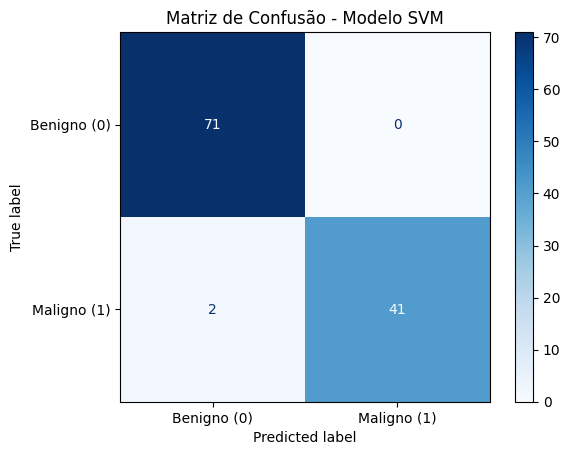

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svm = df_results.index[0]

modelo_svm = models[svm]

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor_classificacao), 
    ('classifier', SVC(random_state=42))
])

pipe.fit(X_train_2, y_train_2)
y_pred_2 = pipe.predict(X_test_2)

cm = confusion_matrix(y_test_2, y_pred_2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Benigno (0)', 'Maligno (1)']
)

disp.plot(cmap='Blues', values_format='d')
plt.title(f"Matriz de Confusão - Modelo SVM")
plt.show()

Como dito anteriormente, sempre que o modelo fala que um tumor é maligno, o tumor é realmente maligno. Porém ele deixou de identificar 2 tumores malignos.

# 3.SUBMISSÃO NO KAGGLE

In [75]:
df_test_regressao = pd.read_csv(r"C:\Users\felip\ufrj-analytica-training\entregaveis\machine_learning\regressao\test.csv")

X_regressao = df_regressao.drop(columns='score', axis=1)
y_regressao = df_regressao['score']

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_regressao), 
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
pipe_rf.fit(X_regressao, y_regressao)

previsoes_notas = pipe_rf.predict(df_test_regressao)

submissao_regressao = pd.DataFrame({
    'id': range(len(previsoes_notas)),
    'score': previsoes_notas
})

submissao_regressao.to_csv("submissao_regressao.csv", index=False)

In [76]:
df_test_classificacao = pd.read_csv(r"C:\Users\felip\ufrj-analytica-training\entregaveis\machine_learning\classiicacao\test2.csv")

X_classificacao = df_classificacao.drop(columns='diagnosis', axis=1)
y_classificacao = df_classificacao['diagnosis']

pipe_svm = Pipeline(steps=[
    ('preprocessor', preprocessor_classificacao),
    ('classifier', SVC(random_state=42))
])

pipe_svm.fit(X_classificacao, y_classificacao)
previsoes_cancer = pipe_svm.predict(df_test_classificacao)

submissao_classificacao = pd.DataFrame({
    'id': range(len(previsoes_cancer)),
    'diagnosis': previsoes_cancer
})

submissao_classificacao['diagnosis'] = submissao_classificacao['diagnosis'].map({1: 'M', 0: 'B'})
submissao_classificacao.to_csv("submissao_classificacao.csv", index=False)